In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv('cars.csv')
print(df.shape)

(8128, 5)


In [4]:
df = pd.get_dummies(df, columns=['fuel', 'owner', 'brand'], drop_first=True)
print(df.shape)

(8128, 40)


In [5]:
df_clean = df[df['selling_price'] <= 5000000]
print(df_clean.shape)

(8011, 40)


In [6]:
X = df_clean.drop('selling_price', axis=1)
Y = df_clean['selling_price']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, Y_train)
Y_pred = lr.predict(X_test)

rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
r2 = r2_score(Y_test, Y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 290117.0889148688
R2 Score: 0.7039034163898228


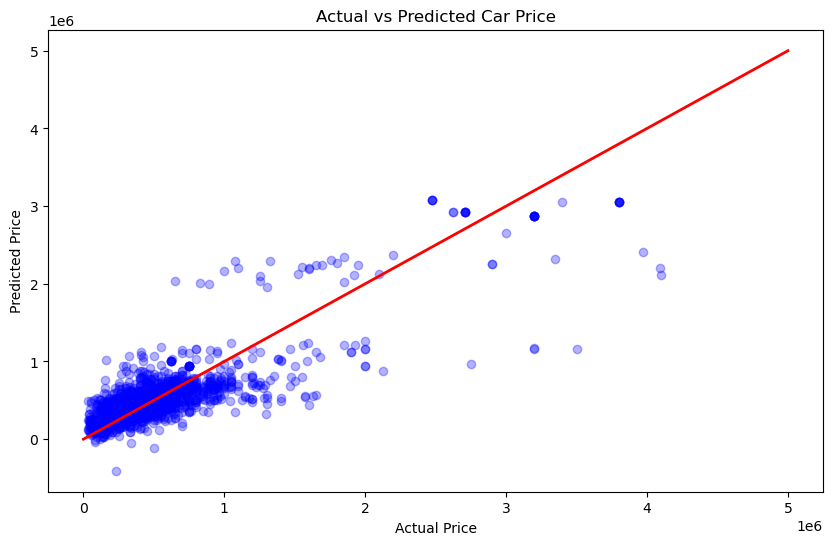

In [7]:
plt.figure(figsize=(10,6))
plt.scatter(Y_test, Y_pred, alpha=0.3, color='blue')
plt.plot([0, 5000000], [0, 5000000], color='red', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Price')
plt.savefig('actual_vs_predicted.png')
plt.show()

In [8]:
import pickle

with open('car_price_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

print("Model saved successfully!")

Model saved successfully!
